In [97]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import fetch_california_housing
from joblib import dump
import math
from scipy.io import loadmat

import matplotlib.pyplot as plt


In [119]:
#read a matlab struct from a mat file and save it into a pd dataframe

mat = loadmat('../input/microstructures_object_array_final.mat')
raw_rows = mat['final_microstructure_array'][0]

column_names = raw_rows[0].dtype.names

data = []

for raw_row in raw_rows:
    row=[]
    for array in raw_row:
        if len(array[0]) == 1:
            row.append(array[0][0])
        else:
            row.append(array[0])

    data.append(row)

data

df =  pd.DataFrame(data, columns= column_names )


num_rows = df.shape[0]

# Separate the last 5 rows into a validation set
validation_df = df.iloc[num_rows - 6:]

# The rest of the rows go into the training set
training_df = df.iloc[:num_rows - 6]

df = training_df

validation_df

df["R11"] = df["yield_stress_XX"]/df["yield_stress_ZZ"]

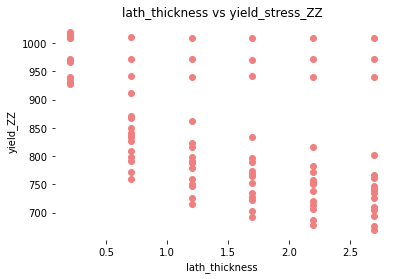

In [99]:
plt.scatter(df['lath_thickness'], df['yield_stress_ZZ'], color = 'lightcoral')
plt.title('lath_thickness vs yield_stress_ZZ')
plt.xlabel('lath_thickness')
plt.ylabel('yield_ZZ')
plt.box(False)
plt.show()



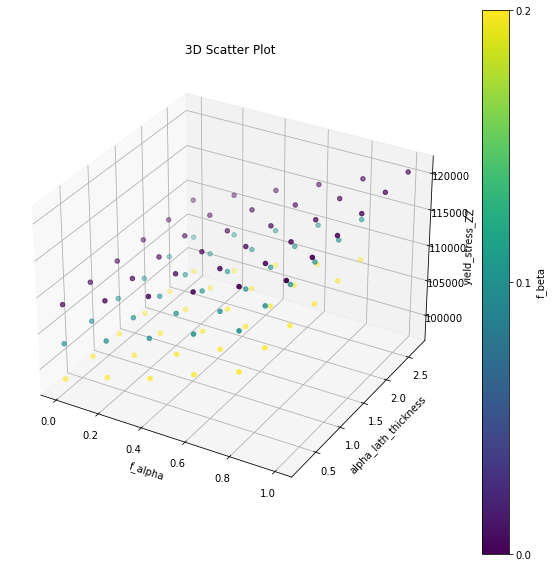

In [125]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the data
sc = ax.scatter(df['f_alpha'], df['lath_thickness'], df['Ez'], c=df['f_beta'])

# Set labels and title
ax.set_xlabel('f_alpha')
ax.set_ylabel('alpha_lath_thickness')
ax.set_zlabel('yield_stress_ZZ')
ax.set_title('3D Scatter Plot')

# Add a colorbar
cbar = fig.colorbar(sc, label='f_beta')
cbar.set_ticks([0.0, 0.1, 0.2])  # Set colorbar ticks to 0.0, 0.1, and 0.2


# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/plot.jpeg')



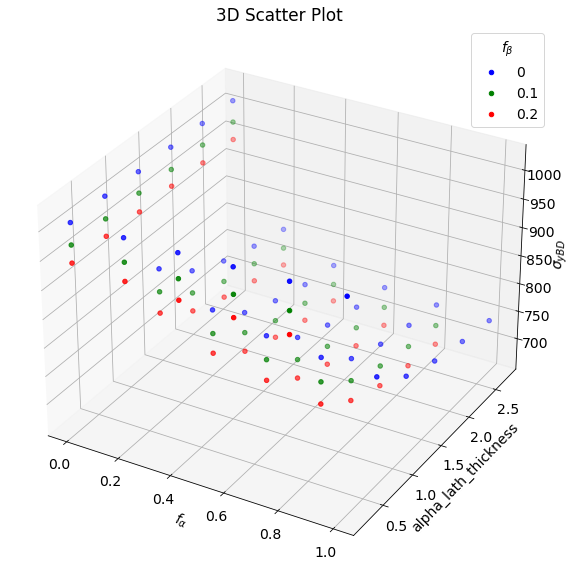

In [142]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'font.size': 14})


# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Define the colors for each value of f_beta
colors = ['blue', 'green', 'red']  # Modify this list to match your data
labels = ['0', '0.1', '0.2']  # Modify this list to match your data

# Plot the data for each value of f_beta
for i, value in enumerate(df['f_beta'].unique()):
    mask = df['f_beta'] == value
    ax.scatter(df['f_alpha'][mask], df['lath_thickness'][mask], df['yield_stress_ZZ'][mask], color=colors[i], label=labels[i])

# Set labels and title
ax.set_xlabel('$f_{\\alpha }$')
ax.set_ylabel('$t_{\alpha}')
ax.set_zlabel('$\\sigma_{y BD}$')
ax.set_title('3D Scatter Plot')

# Add a legend with a title
ax.legend(title='$f_\\beta$')

# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/plot.jpeg')

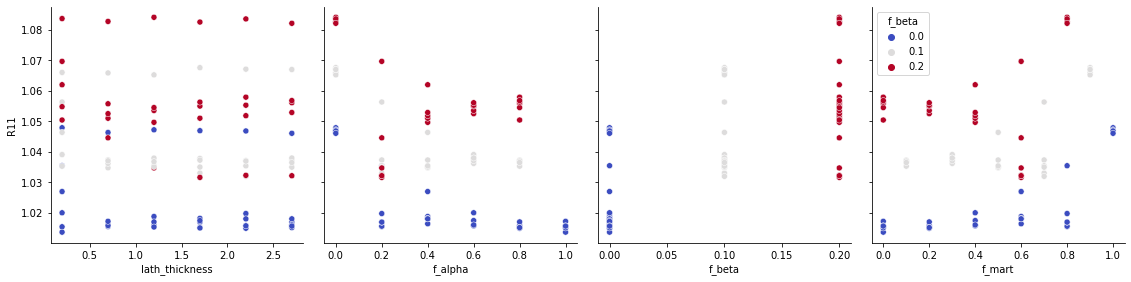

In [121]:
import seaborn as sns

# Create a PairGrid
g = sns.PairGrid(df, y_vars=['R11'], x_vars=['lath_thickness', 'f_alpha', 'f_beta', 'f_mart'], height=4)

# Map a scatter plot to the upper triangle, color points by 'f_beta'
g.map(sns.scatterplot, hue=df['f_beta'], palette='coolwarm')

# Add a legend
plt.legend(title='f_beta')

# Show the plot
plt.show()

In [102]:
# Polynomial multi-variate regression

# Select appropriate features from the dataset
X = df[['lath_thickness','f_alpha','f_beta']].values

properties = ['yield_stress_ZZ','yield_stress_XX','yield_stress_XY','yield_stress_XZ','Ex','Ez','Gxy','Gxz','Pxz','Pyx']

property = 'Ez'
y = df[property].values

# Polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Linear Regression model
model = LinearRegression()
model.fit(X_poly, y)

r_sq = model.score(X_poly,y)
print(f"coefficient of determination: {r_sq}")

print(f"intercept: {model.intercept_}")
print(f"slope: {model.coef_}")


# Calculate error with validation data set:

error = []

for index, row in validation_df.iterrows():
    
    print(row['f_alpha'] + row['f_beta'])
    
    new_data = np.array([row['lath_thickness'], row['f_alpha'], row['f_beta']]).reshape(1,-1)  # Example values
    new_data_poly = poly.transform(new_data)


    # Predicting the price
    predicted_y = model.predict(new_data_poly)

    error.append( (predicted_y[0] - row[property]) / row[property] * 100)

print('error_percentage',error)


coefficient of determination: 0.9997575841332703
intercept: 108624.14066160381
slope: [ 0.00000000e+00  3.86725672e+01  1.14741566e+04 -5.49505718e+04
 -9.72184267e+00 -4.40526546e+01 -8.80833958e+01  6.33706116e+02
 -5.35505798e+03  1.12540548e+04]
1.0
0.0
0.9
1.0
0.8
0.42000000000000004
error_percentage [0.030217152688114444, -0.011616737791946153, 0.031911436100850996, 0.03789691590487569, -0.27123511955784785, -4.0753960083261327e-05]


In [103]:
## Create Regression model for all independent variables and save them:

from joblib import load

# Select appropriate features from the dataset
X = df[['lath_thickness','f_alpha','f_beta']].values


properties = ['yield_stress_ZZ','yield_stress_XX','yield_stress_XY','yield_stress_XZ','Ex','Ez','Gxy','Gxz','Pxz','Pyx']

for property in properties:
    y = df[property].values

    # Polynomial features
    poly = PolynomialFeatures(degree=6)
    X_poly = poly.fit_transform(X)

    # Linear Regression model
    model = LinearRegression()
    model.fit(X_poly, y)

    dump(model, f'../data/models_saved/{property}_model.joblib')
    dump(poly, f'../data/models_saved/{property}_poly_transformer.joblib')


In [104]:
hardening = df['yield_stress_hardening_ZZ'].values

for i in range(0,len(hardening[0])):
    # values = [sub_arr[0] for sub_arr in hardening]
    stress_values_this_plastic = [sub_arr[i] for sub_arr in hardening]
    poly = PolynomialFeatures(degree=6)
    X_poly = poly.fit_transform(X)

    # Linear Regression model
    model = LinearRegression()
    model.fit(X_poly, stress_values_this_plastic)

    dump(model, f'../data/models_saved/hardening_{i}_model.joblib')
    dump(poly, f'../data/models_saved/hardening_{i}_poly_transformer.joblib')


plastic_strain = df['plastic_strain_ZZ'].values

plastic_strain_average_list = []

for i in range(len(plastic_strain[0])):

    plastic_values_this_strain = [sub_array[i] for sub_array in plastic_strain]
    plastic_strain_average_list.append( sum(plastic_values_this_strain) / len(plastic_values_this_strain) )

In [111]:
## Load Model and predict properties for a given microstructure

properties = ['yield_stress_ZZ','yield_stress_XX','yield_stress_XY','yield_stress_XZ','Ex','Ez','Gxy','Gxz','Pxz','Pyx']

pred_prop_dict = {}

for property in properties:

    # Load the model and the transformer
    model = load(f'../data/models_saved/{property}_model.joblib')
    poly = load(f'../data/models_saved/{property}_poly_transformer.joblib')

    # New data
    new_data = np.array([[0.4,0.33,0.09]])  # Example values

    # Transform the new data using the loaded transformer
    new_data_poly = poly.transform(new_data)

    # Use the loaded model to make a prediction
    predicted_y = model.predict(new_data_poly)

    pred_prop_dict[property] = predicted_y[0]


pred_prop_dict['sigma_0'] = []
for i in range(0,len(plastic_strain_average_list)):

    # Load the model and the transformer
    model = load(f'../data/models_saved/hardening_{i}_model.joblib')
    poly = load(f'../data/models_saved/{property}_poly_transformer.joblib')

    # New data
    new_data = np.array([[0.4,0.33,0.09]])  # Example values
    # Transform the new data using the loaded transformer
    new_data_poly = poly.transform(new_data)

    # Use the loaded model to make a prediction
    predicted_y = model.predict(new_data_poly)
    pred_prop_dict['sigma_0'].append(predicted_y[0])

pred_prop_dict['strain_0'] = plastic_strain_average_list

pred_prop_dict

{'yield_stress_ZZ': 899.8388671875,
 'yield_stress_XX': 940.2398624420166,
 'yield_stress_XY': 478.7259521484375,
 'yield_stress_XZ': 487.9737548828125,
 'Ex': 110639.298828125,
 'Ez': 107597.046875,
 'Gxy': 41831.091796875,
 'Gxz': 43069.96875,
 'Pxz': 0.32777953147888184,
 'Pyx': 0.30417370796203613,
 'sigma_0': [899.8388671875,
  939.86376953125,
  973.5888671875,
  1001.49755859375,
  1024.5673828125,
  1043.36474609375,
  1058.4951171875,
  1070.959228515625,
  1080.677734375,
  1089.152587890625,
  1096.2607421875,
  1102.37646484375,
  1108.1943359375,
  1112.9052734375,
  1117.63623046875,
  1121.521484375,
  1125.05810546875,
  1128.72900390625,
  1131.5048828125,
  1134.70703125,
  1137.08203125,
  1139.419921875,
  1141.93359375,
  1143.7021484375,
  1146.130859375,
  1147.7001953125,
  1149.4453125,
  1151.2421875,
  1152.4482421875,
  1154.435546875,
  1155.5234375,
  1156.94921875,
  1158.21875,
  1159.1298828125,
  1160.7509765625,
  1161.4814453125,
  1162.7734375,
  11

In [112]:
#write material INP:

import importlib
import write_material_inp

importlib.reload(write_material_inp)

write_material_inp.write_inp(pred_prop_dict, '../data/Val_2_interp.inp')

# ## Write Material info in Abaqus inp format:

# #Calculate Hill Parameters from yield stresses
# sigma_0 = pred_prop_dict['yield_stress_ZZ']
# R11 = pred_prop_dict['yield_stress_XX']/sigma_0
# R22 = R11
# R33 = 1
# R12 = pred_prop_dict['yield_stress_XY']/(sigma_0/math.sqrt(3))
# R13 = pred_prop_dict['yield_stress_XZ']/(sigma_0/math.sqrt(3))
# R23 = R13

# hardening_string = ''
# for i in range(len(pred_prop_dict['strain_0'])):
#     hardening_string += f"\n{pred_prop_dict['sigma_0'][i]},{pred_prop_dict['strain_0'][i]}"

# #Write Material info in Abaqus inp format:
# Material_Abaqus_text =f'''**
# *Material, name=Material-1
# *Elastic, type=ENGINEERING CONSTANTS
# {pred_prop_dict['Ex']},{pred_prop_dict['Ex']},{pred_prop_dict['Ez']}, {pred_prop_dict['Pyx']}, {pred_prop_dict['Pxz']}, {pred_prop_dict['Pxz']}, {pred_prop_dict['Gxy']}, {pred_prop_dict['Gxz']}
# {pred_prop_dict['Gxz']},
# *Plastic{hardening_string}
# *Potential
# {R11}, {R22},  {R33},  {R12},  {R12},  {R23}'''


# with open('../data/material.inp', 'w') as f:
#     # Write the string to the file
#     f.write(Material_Abaqus_text)


In [107]:
## Write INP for a CP result
import importlib
import write_material_inp

importlib.reload(write_material_inp)

# Get the row number
# row_number = 0 #CP_HT900
row_number = -1

# Convert the row into a dictionary
row_dict = validation_df.iloc[row_number].to_dict()

row_dict["strain_0"] = row_dict['plastic_strain_ZZ']
row_dict["sigma_0"] = row_dict['yield_stress_hardening_ZZ']


write_material_inp.write_inp(row_dict, '../data/material_second_validation_CP.inp')


In [108]:
row_dict

{'lath_thickness': 0.4,
 'f_alpha': 0.33,
 'f_beta': 0.09,
 'f_mart': 0.58,
 'folder': './temp_102',
 'yield_stress_ZZ': 899.9236774017734,
 'Ez': 107471.1554888258,
 'yield_stress_hardening_ZZ': array([ 899.9236774 ,  940.88434008,  975.11709166, 1002.87825948,
        1024.90610271, 1042.52004098, 1056.79866818, 1068.68731734,
        1079.11720013, 1087.90983109, 1095.96261093, 1103.13769944,
        1109.61824327, 1115.76295471, 1120.99334379, 1126.08311319,
        1130.54326763, 1134.60914605, 1138.51853679, 1141.66368259,
        1144.87453145, 1147.5030278 , 1149.97441747, 1152.37164378,
        1154.21498901, 1156.30126261, 1157.83549125, 1159.45125389,
        1161.00576807, 1162.20310271, 1163.74274098, 1164.69290535,
        1165.91304109, 1167.00295451, 1167.9061938 , 1169.16625561,
        1169.80033706, 1170.84211307, 1171.6386006 , 1172.41442836,
        1173.42976588, 1173.95916256, 1174.92408428, 1175.50641664,
        1176.23843662, 1177.05937938, 1177.55544013, 1178

In [109]:
## Linear_Interpolation in 3D unstructured grid

import numpy as np
from scipy.interpolate import griddata

property = 'yield_stress_ZZ'

# Define the points where you know the function values
points = df[['lath_thickness','f_alpha','f_beta']].values # 100 points in 3D
values = df[property].values

# Define the point where you want to interpolate
interp_point = np.array([0.5, 0.0, 0.0])

# Perform the interpolation
interp_value = griddata(points, values, [interp_point], method='linear')

interp_value

# Calculate error with validation data set:

error = []

for index, row in validation_df.iterrows():

    
    interp_point = np.array([row['lath_thickness'], row['f_alpha'], row['f_beta']]).reshape(1,-1)  # Example values
    print(interp_point)
    interp_value = griddata(points, values, [interp_point], method='linear')


    predicted_y = interp_value[0]
    error.append( ( (predicted_y - row[property]) / row[property] ) * 100 )

print('error_percentage',error)


[[1.42 0.88 0.12]]
[[0.85 0.   0.  ]]
[[2.35 0.8  0.1 ]]
[[1.35 1.   0.  ]]
[[0.7  0.61 0.19]]
[[0.4  0.33 0.09]]
error_percentage [array([0.72056694]), array([0.03689016]), array([0.21343676]), array([0.16543394]), array([0.06666989]), array([1.69950986])]


In [110]:
#RBF Interpolation

import numpy as np
from scipy.interpolate import RBFInterpolator


property = 'yield_stress_ZZ'

# Define the points where you know the function values
points = df[['lath_thickness','f_alpha','f_beta']].values # 100 points in 3D
values = df[property].values

# Define the point where you want to interpolate
rbf = RBFInterpolator(points, values, kernel = 'quintic')


# interp_value = rbf([[2.35, 0.8, 0.1]])

# Calculate error with validation data set:
error = []

for index, row in validation_df.iterrows():

    
    interp_point = np.array([row['lath_thickness'], row['f_alpha'], row['f_beta']]).reshape(1,-1) 
    interp_value = rbf( interp_point )

    predicted_y = interp_value[0]

    print(predicted_y, row[property])

    error.append( ( (predicted_y - row[property]) / row[property] ) * 100 )

print('error_percentage',error)


732.999120767173 728.5105229066945
1007.6741669099833 1009.2568996069514
713.662810832186 709.2249374532935
781.0877895911908 779.3003459255983
775.1238308675223 774.9511472907604
915.4726713176808 899.9236774017734
error_percentage [0.6161335655893363, -0.15682158800048057, 0.6257356650244358, 0.22936518313353124, 0.022283156475808006, 1.7278125141456344]
